# Dataset Insights and Characterization

**Purpose**: Comprehensive characterization of the Python configuration recommendation dataset for publication.

**Dataset**: 1,465 repositories $\times$ 32 features (27 numeric + 5 boolean) $\times$ 10 labels (multi-label)

**Analyses**:
1. Feature distributions (numeric and boolean structural features)
2. Label analysis (frequencies, multi-label statistics, configuration patterns)
3. Detailed Distributions (star distribution, temporal patterns)

## Setup and Imports

In [341]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib_venn import venn3

from src.utils import load_latest_dataset, print_dataset_schema

In [342]:
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.format"] = "pdf"
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab10.colors)

### Output files directories creation

In [343]:
artifacts_dir = Path("artifacts")

distributions_dir = artifacts_dir / "distributions"
labels_dir = artifacts_dir / "labels"
distributions_detailed_dir = distributions_dir / "detailed"

for dir_path in [distributions_dir, labels_dir, distributions_detailed_dir]:
    dir_path.mkdir(parents=True, exist_ok=True)

## Data Loading and Validation

In [344]:
df, manifest, version_path = load_latest_dataset(data_dir="../data/processed")


Dataset loaded: 1465 records
  Version: 1.0.1
  Created: 2026-04-01T19:45:24.483060+00:00
  Git commit: 4f490c29


In [345]:
label_cols = [
    "has_pyproject_toml",
    "has_dockerfile",
    "has_github_actions",
    "has_tox_ini",
    "has_conda_env_file",
    "has_docker_compose",
    "has_precommit_config",
    "has_setup_py",
    "has_requirements_txt",
    "has_makefile",
]

schema = print_dataset_schema(df, label_cols)


id_col = schema["id_col"]
label_cols = schema["label_cols"]
feature_cols = schema["feature_cols"]

Dataset Schema:
  Total columns: 43
  Identifier: 1 (repo_url)
  Features: 32
  Labels: 10


### Detect nullable values

In [346]:
missing = df[feature_cols + label_cols].isnull().sum()

if missing.sum() > 0:
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame(
        {"Missing Count": missing, "Missing %": missing_pct}
    ).query("`Missing Count` > 0")
    print("Missing values detected:")
    print(missing_df)
else:
    print("No missing values")

No missing values


### Detect duplicates

In [347]:
duplicates = df[df.duplicated(subset=["repo_url"], keep=False)].sort_values("repo_url")

if not duplicates.empty:
    print(f"Found {len(duplicates)} duplicate entries based on repo_url:")
    print(duplicates[["repo_url"]].drop_duplicates())
else:
    print("No duplicate entries based on repo_url")

No duplicate entries based on repo_url


## Dataset presenting

In [348]:
print("Dataset sample:")
df.head()

Dataset sample:


,repo_url,stars,forks,repo_size_kb,open_issues_count,num_files,num_py_files,num_js_files,num_ts_files,num_html_files,...,has_pyproject_toml,has_dockerfile,has_github_actions,has_requirements_txt,has_conda_env_file,has_docker_compose,has_precommit_config,has_setup_py,has_tox_ini,has_makefile
0,https://github.com/0voice/interview_internal_r...,37216,9408,1161,36,163,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,https://github.com/0x4m4/hexstrike-ai,7814,1710,2131,72,13,2,0,0,0,...,False,False,False,True,False,False,False,False,False,False
2,https://github.com/0xAX/linux-insides,32266,3502,21356,34,144,2,0,0,0,...,False,True,True,False,False,False,False,False,False,True
3,https://github.com/0xInfection/Awesome-WAF,7407,1171,30499,1,32,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,https://github.com/1Panel-dev/MaxKB,20621,2738,64312,76,2102,1005,2,316,5,...,True,True,True,False,False,False,False,False,False,False


### Descriptive Statistics

In [349]:
feature_stats = df[feature_cols].describe()

print("Feature Summary Statistics:")
feature_stats

Feature Summary Statistics:


,stars,forks,repo_size_kb,open_issues_count,num_files,num_py_files,num_js_files,num_ts_files,num_html_files,num_css_files,...,other_extensions_count,num_dirs,avg_files_per_dir,avg_py_file_len,avg_test_file_len,avg_nb_cell_count,avg_docs_file_len,num_dependencies,repo_age_days,recent_activity_days
count,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,...,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000
mean,15701.486689,2222.770648,62518.952218,239.133788,811.159044,235.701024,14.235495,25.767918,10.908532,2.947440,...,277.907167,153.507167,8.262648,249.088669,200.186212,5.288874,196.564983,47.478498,2297.384300,0.159727
std,25628.117882,4319.381559,93239.996316,471.774915,1746.696297,425.251951,107.152704,140.725237,72.271534,13.544527,...,1091.639109,376.965153,34.020483,405.716015,335.235272,24.216736,226.909116,197.480392,1672.137134,0.612163
min,4395.000000,16.000000,23.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,5829.000000,634.000000,5568.000000,35.000000,95.000000,28.000000,0.000000,0.000000,0.000000,0.000000,...,19.000000,16.000000,3.920000,128.200000,0.000000,0.000000,92.500000,4.000000,840.000000,0.000000
50%,8625.000000,1123.000000,23520.000000,101.000000,285.000000,85.000000,0.000000,0.000000,0.000000,0.000000,...,53.000000,47.000000,5.140000,191.900000,146.300000,0.000000,143.200000,15.000000,2061.000000,0.000000
75%,15582.000000,2142.000000,75597.000000,253.000000,836.000000,257.000000,3.000000,0.000000,2.000000,1.000000,...,168.000000,140.000000,7.110000,274.400000,279.000000,0.000000,214.800000,38.000000,3619.000000,0.000000
max,418056.000000,66067.000000,493928.000000,7924.000000,30687.000000,4968.000000,2374.000000,3056.000000,1730.000000,299.000000,...,24009.000000,5953.000000,1005.000000,11379.500000,7043.000000,796.000000,2781.900000,6008.000000,6425.000000,8.000000


## 1. Feature Distributions

### 1.1 Continuous Features: Histograms

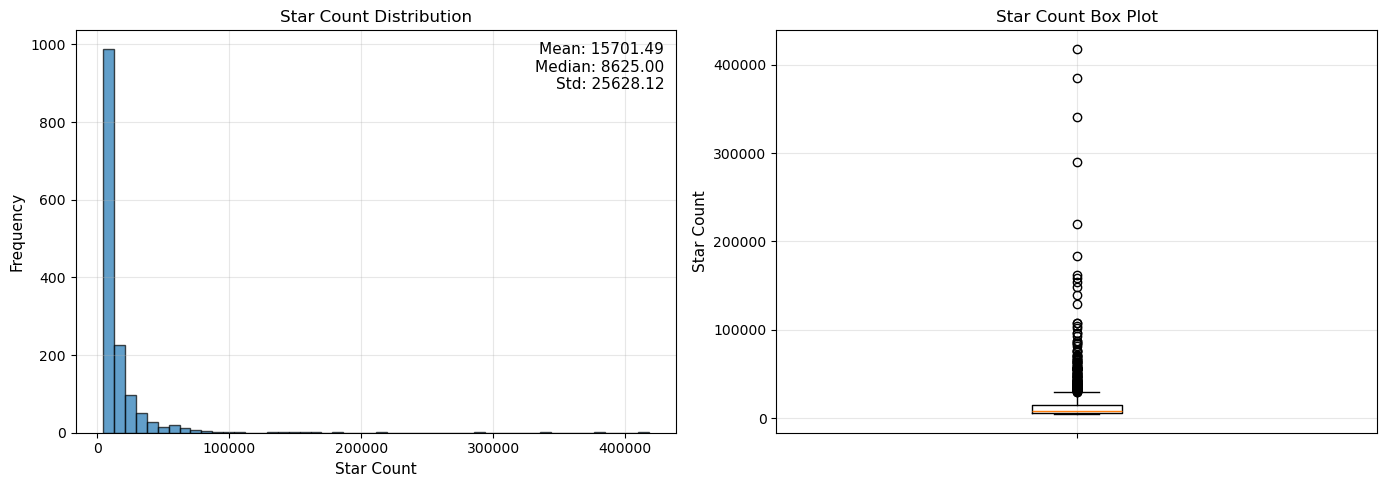

Exported: artifacts/distributions/stars_distribution.pdf


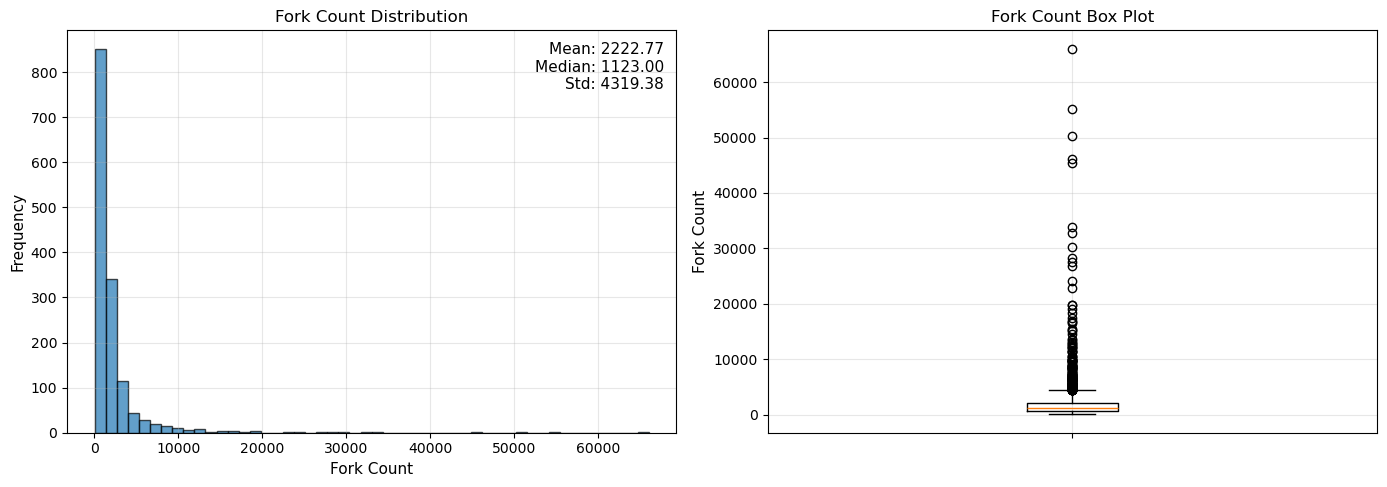

Exported: artifacts/distributions/forks_distribution.pdf


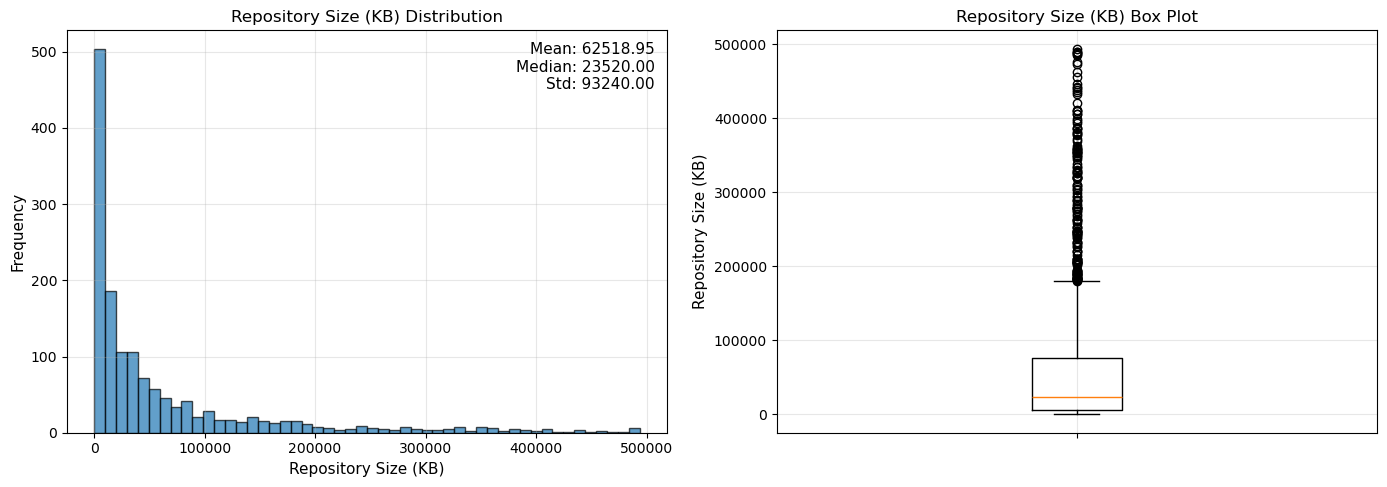

Exported: artifacts/distributions/repo_size_kb_distribution.pdf


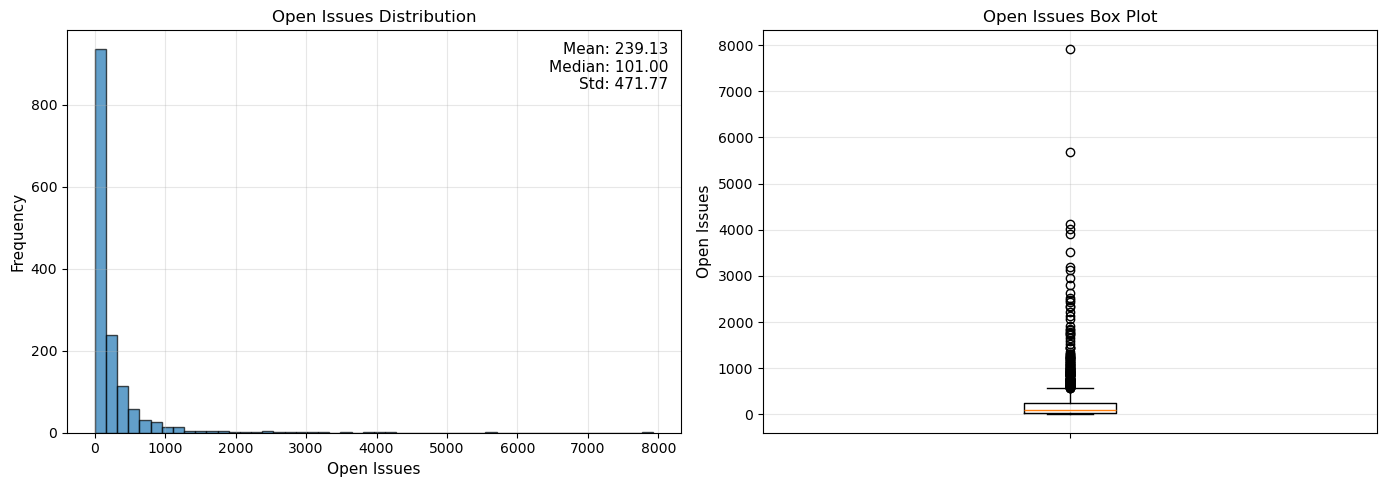

Exported: artifacts/distributions/open_issues_count_distribution.pdf


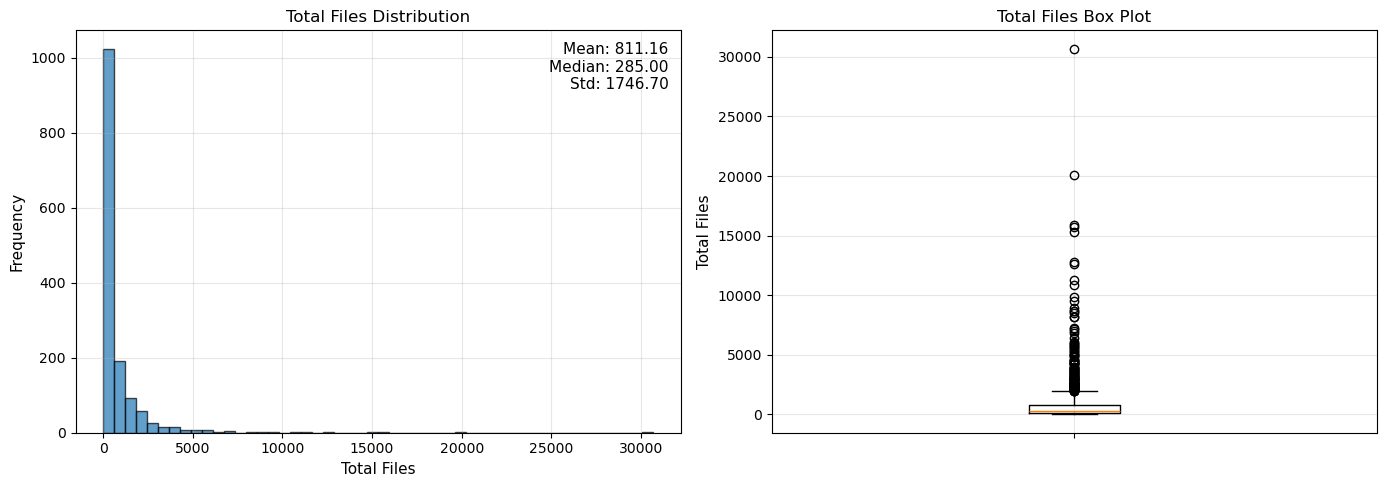

Exported: artifacts/distributions/num_files_distribution.pdf


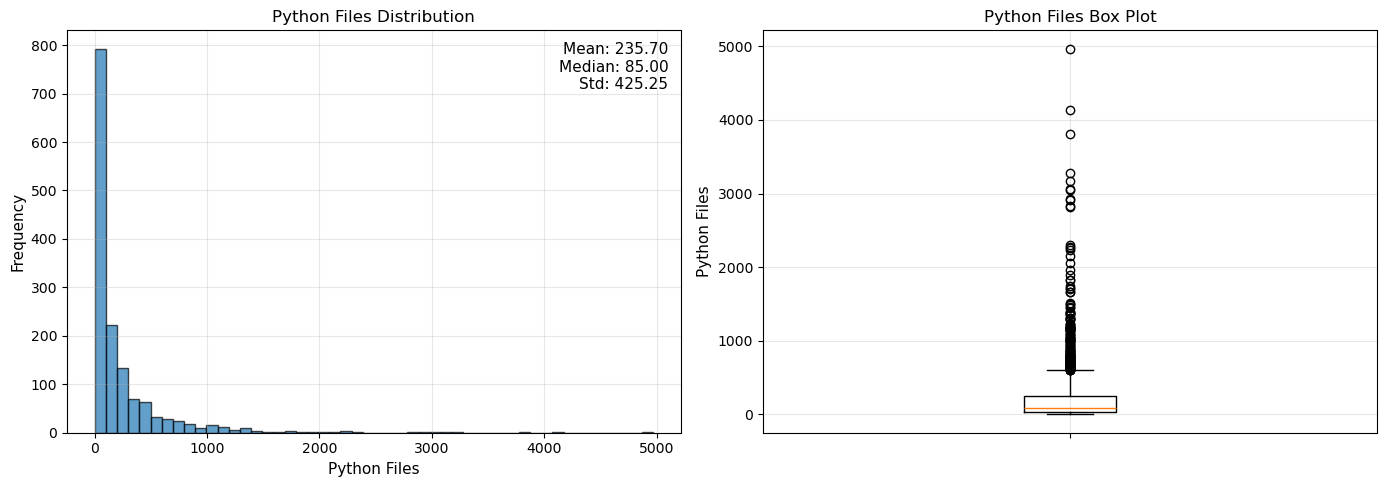

Exported: artifacts/distributions/num_py_files_distribution.pdf


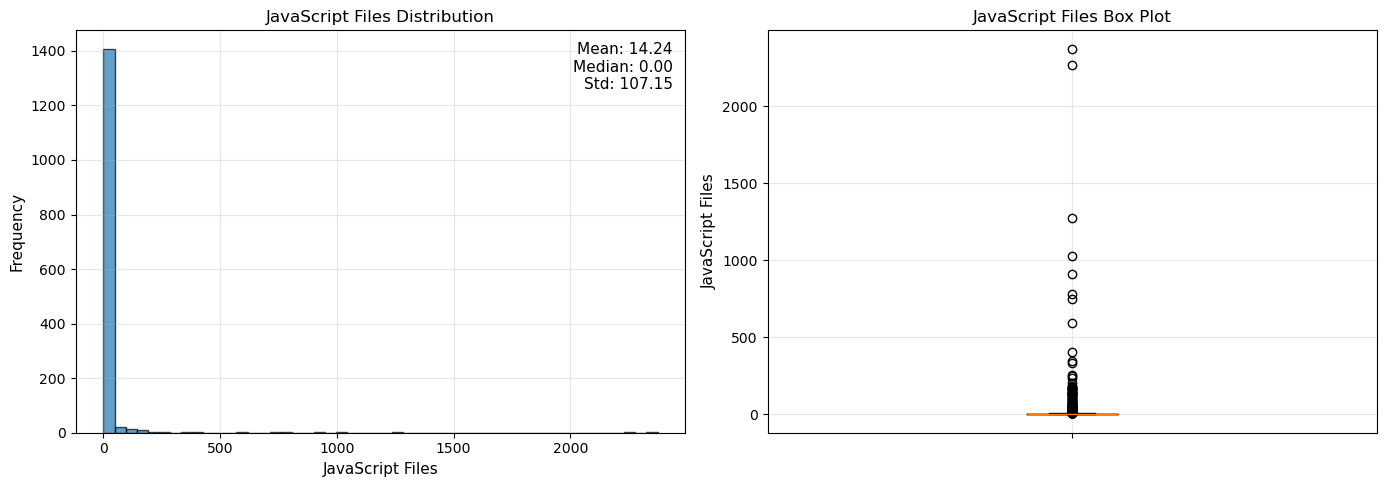

Exported: artifacts/distributions/num_js_files_distribution.pdf


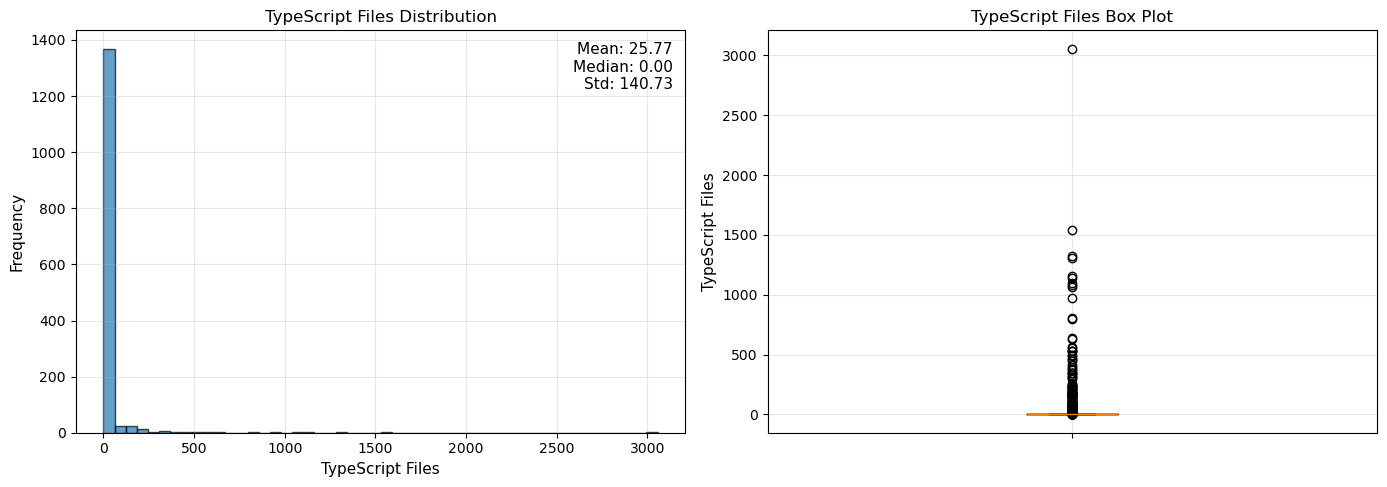

Exported: artifacts/distributions/num_ts_files_distribution.pdf


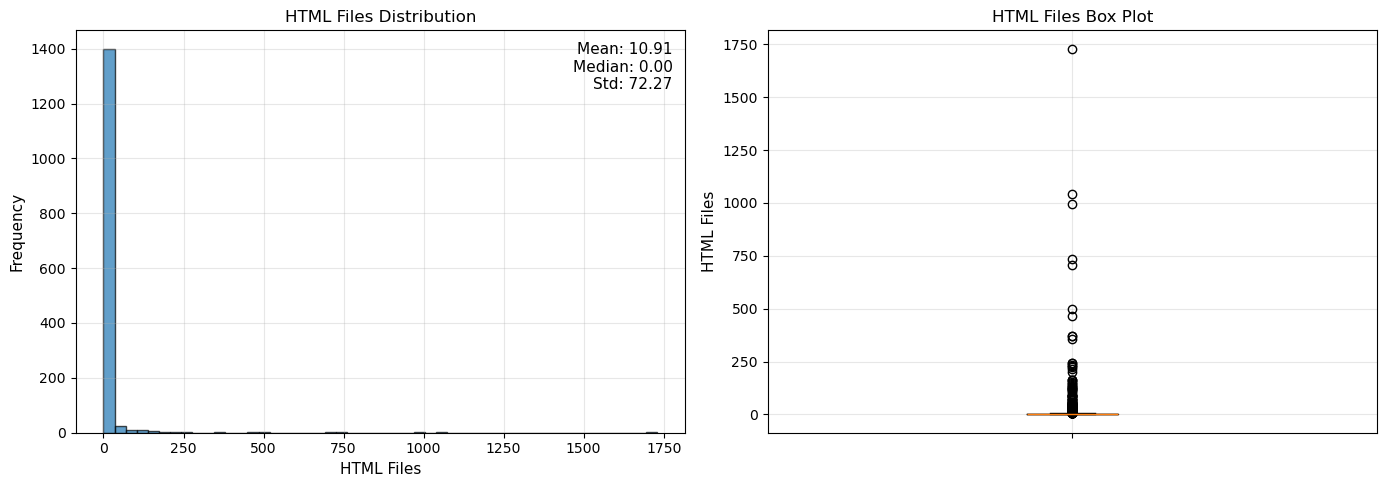

Exported: artifacts/distributions/num_html_files_distribution.pdf


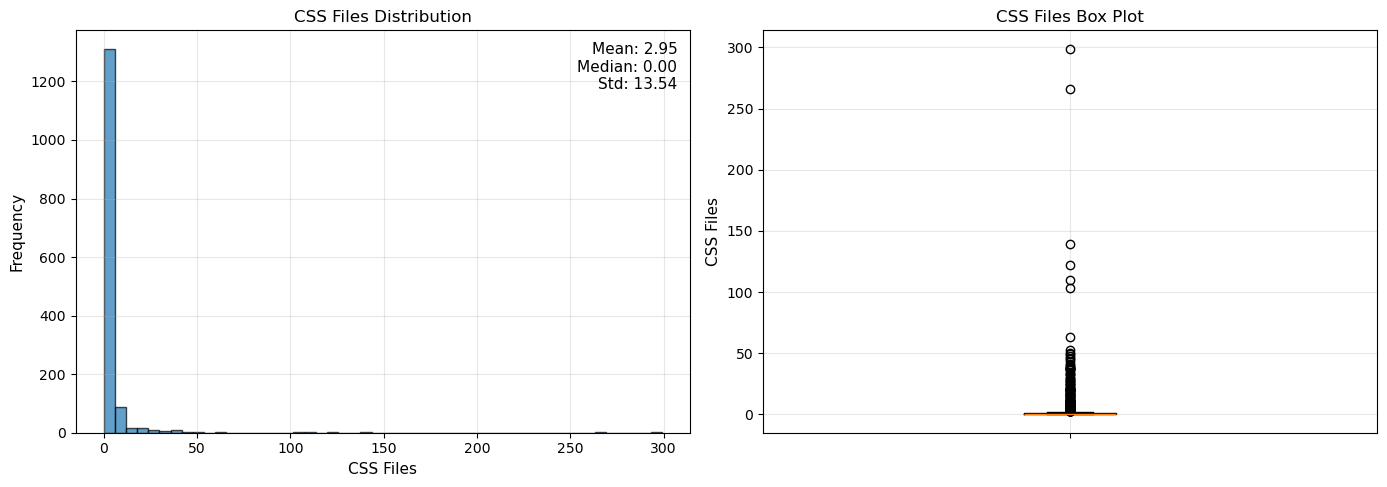

Exported: artifacts/distributions/num_css_files_distribution.pdf


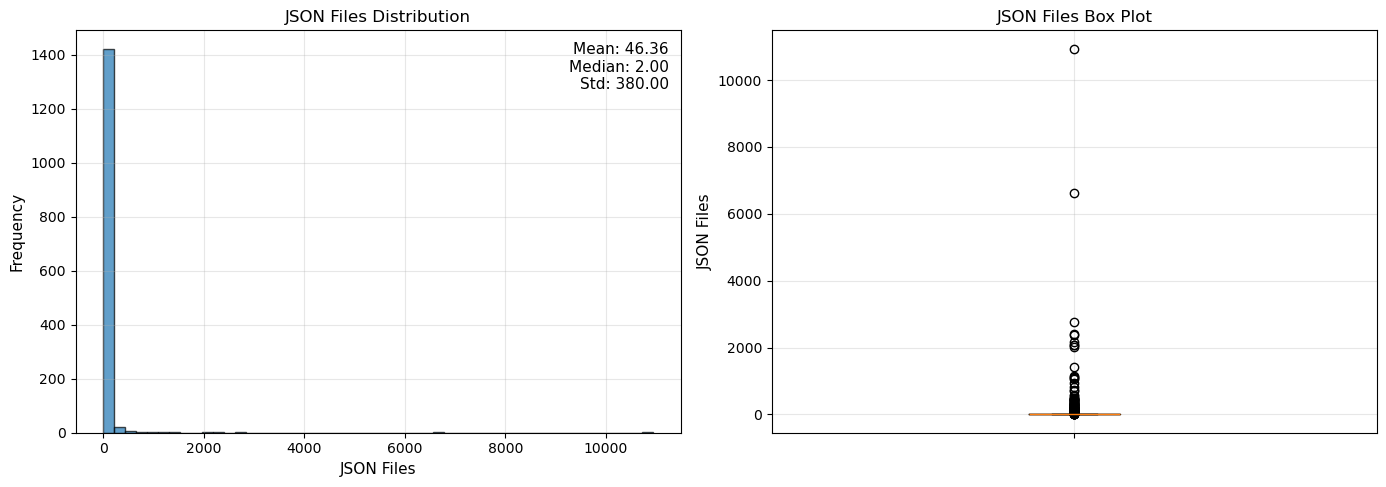

Exported: artifacts/distributions/num_json_files_distribution.pdf


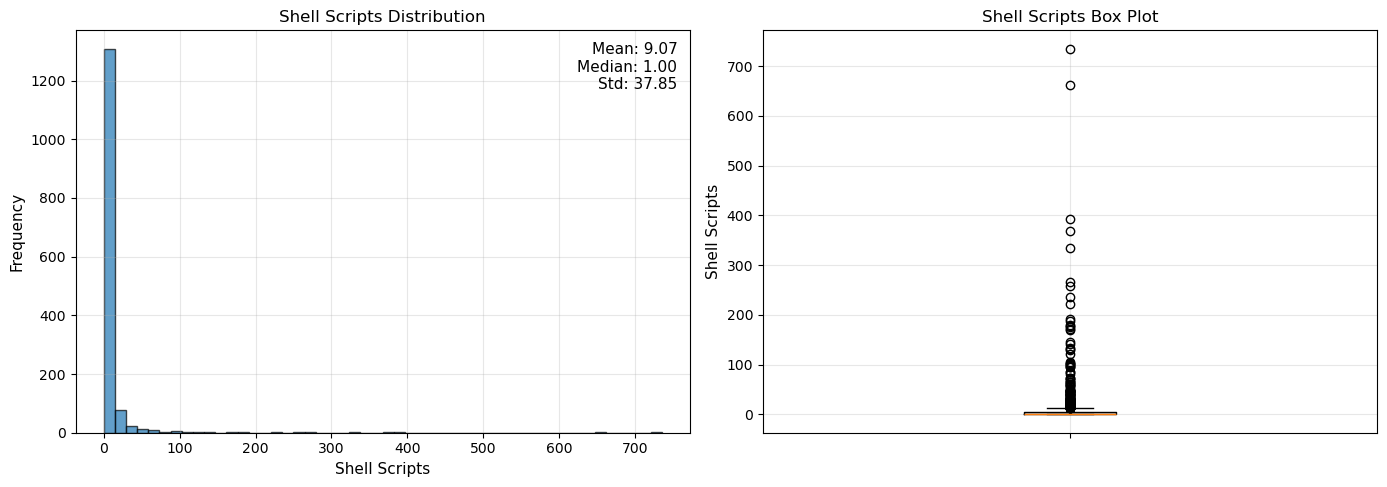

Exported: artifacts/distributions/num_sh_files_distribution.pdf


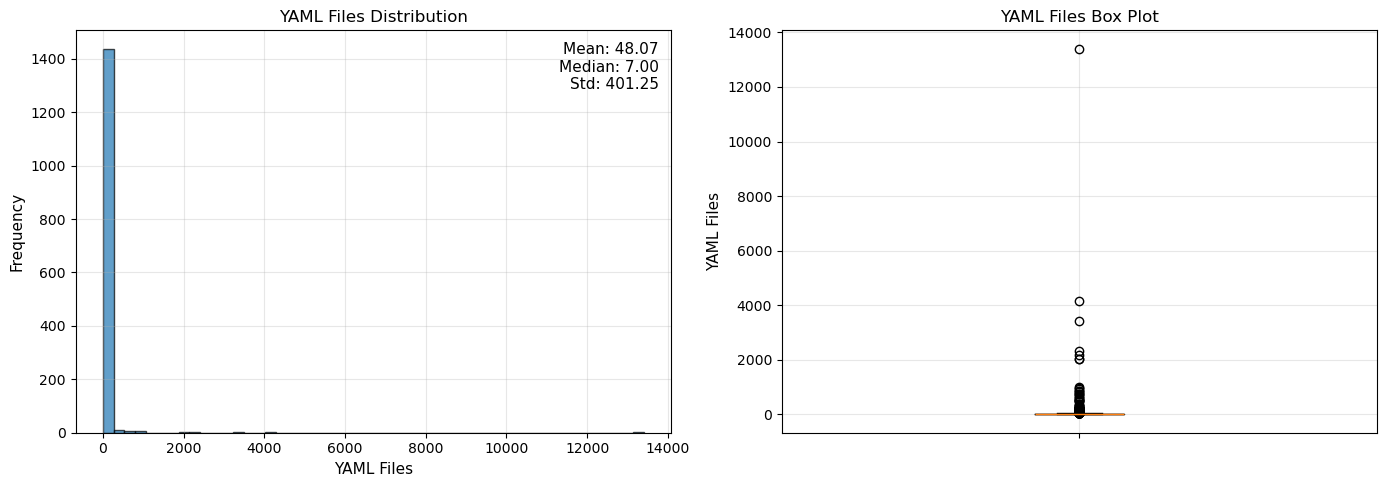

Exported: artifacts/distributions/num_yaml_files_distribution.pdf


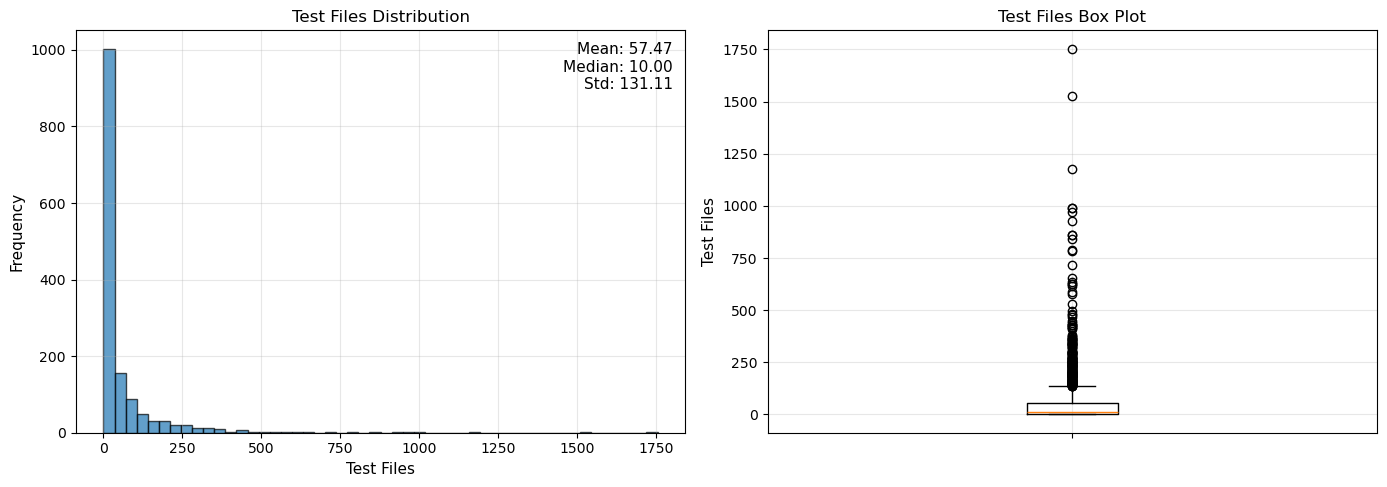

Exported: artifacts/distributions/num_test_files_distribution.pdf


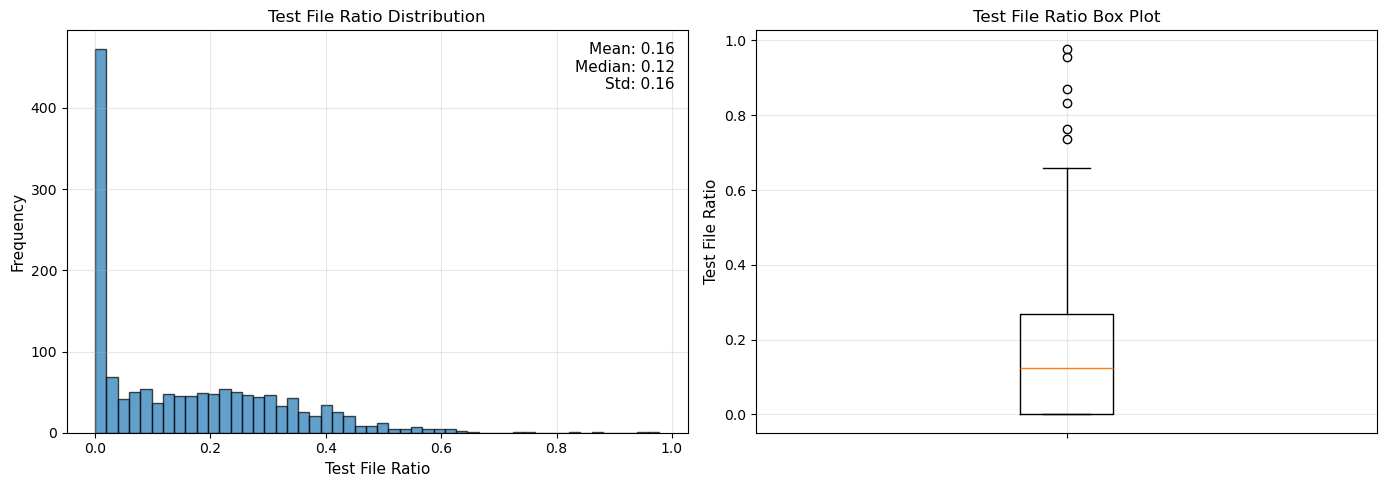

Exported: artifacts/distributions/test_file_ratio_distribution.pdf


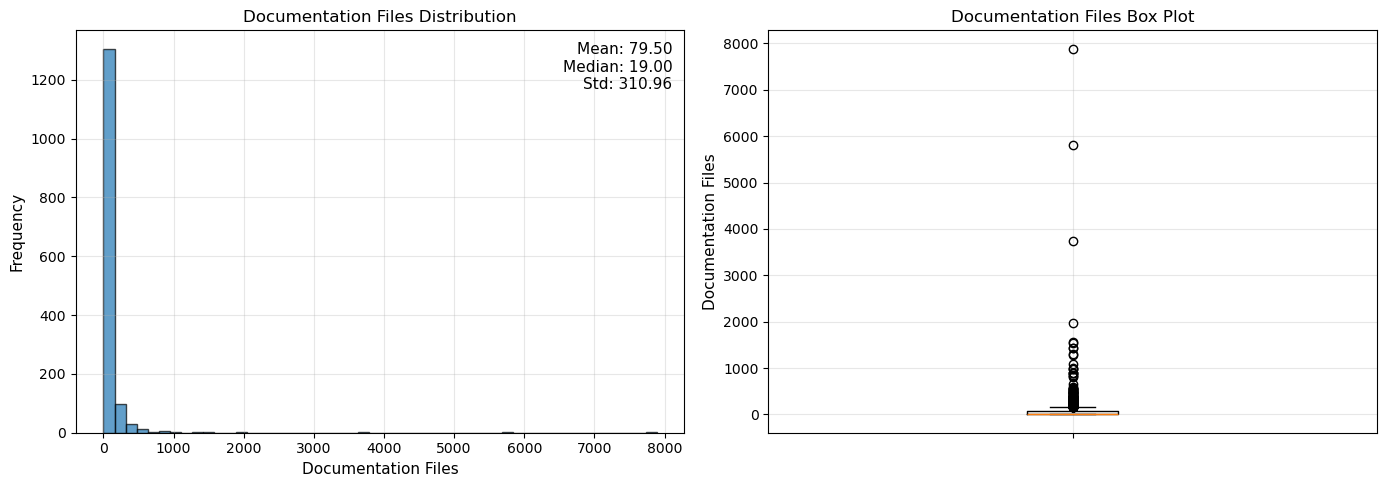

Exported: artifacts/distributions/num_docs_files_distribution.pdf


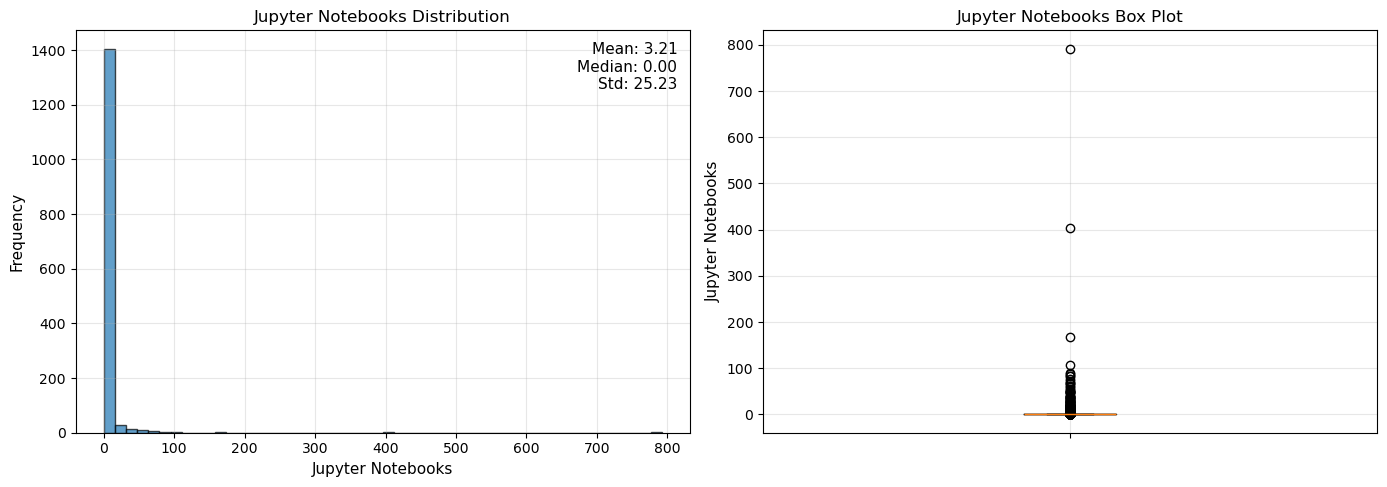

Exported: artifacts/distributions/num_notebooks_distribution.pdf


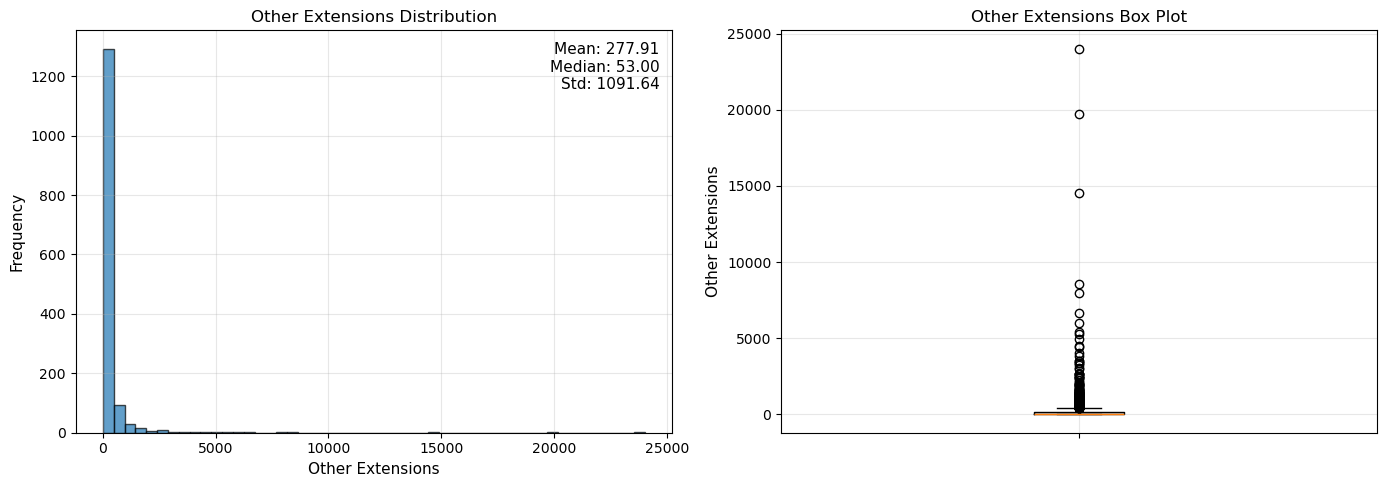

Exported: artifacts/distributions/other_extensions_count_distribution.pdf


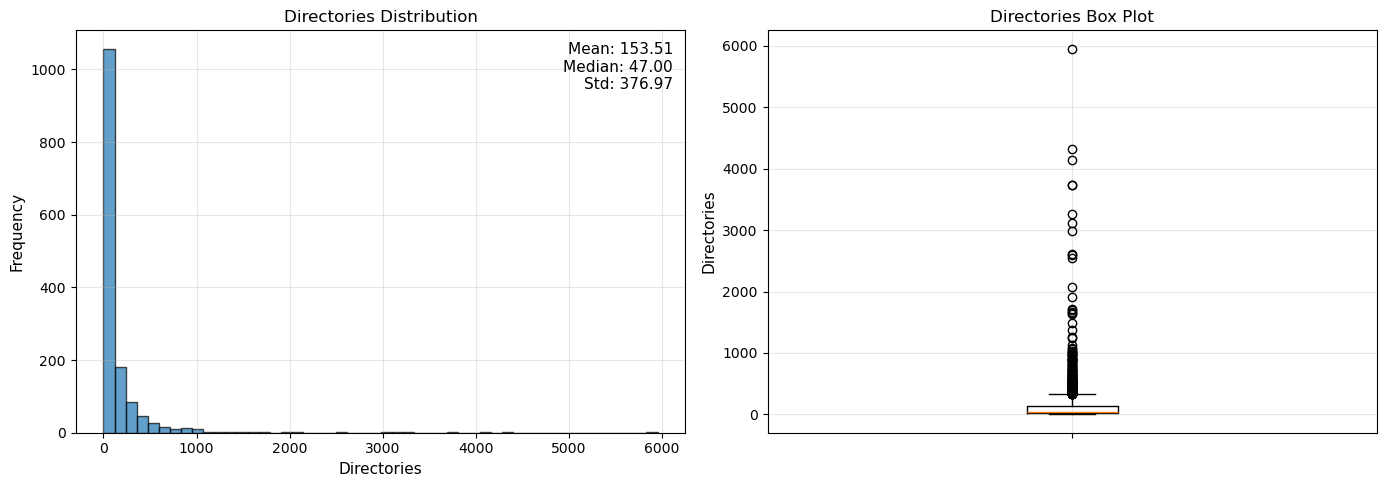

Exported: artifacts/distributions/num_dirs_distribution.pdf


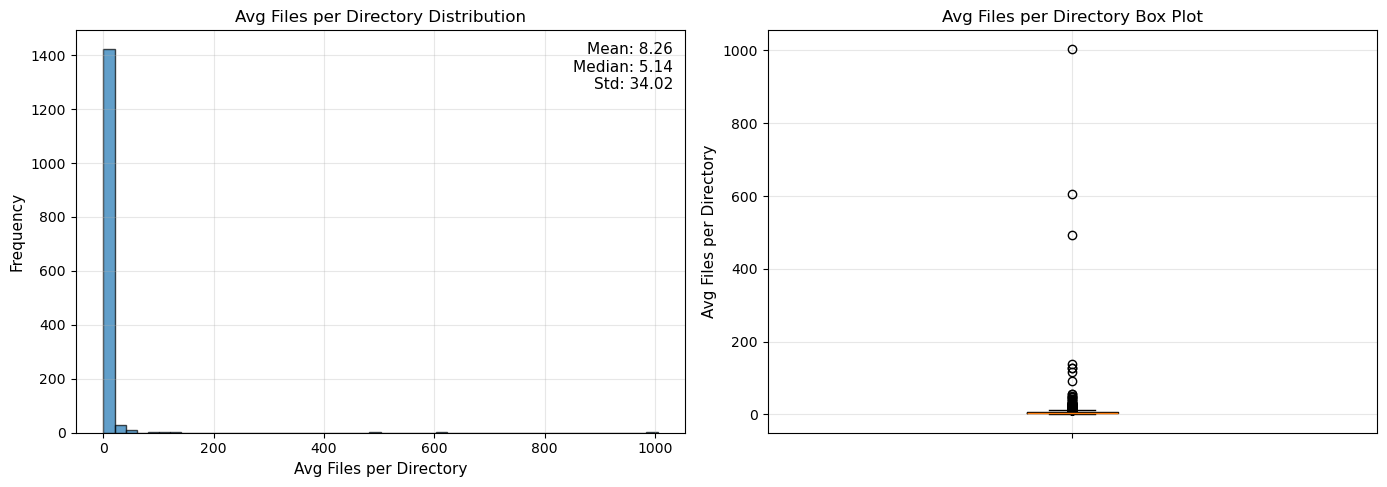

Exported: artifacts/distributions/avg_files_per_dir_distribution.pdf


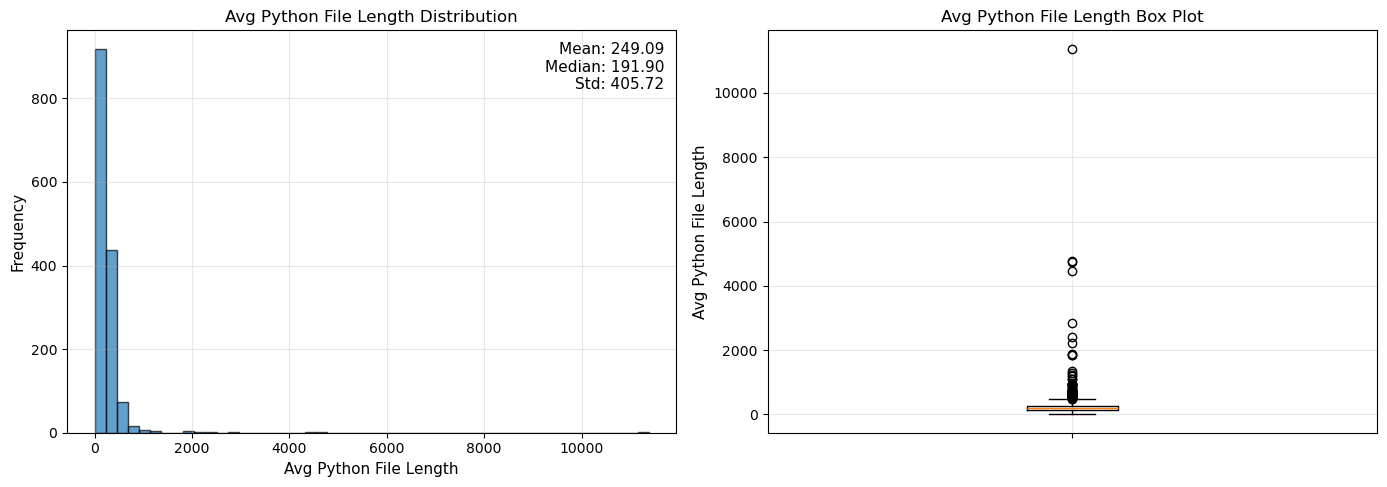

Exported: artifacts/distributions/avg_py_file_len_distribution.pdf


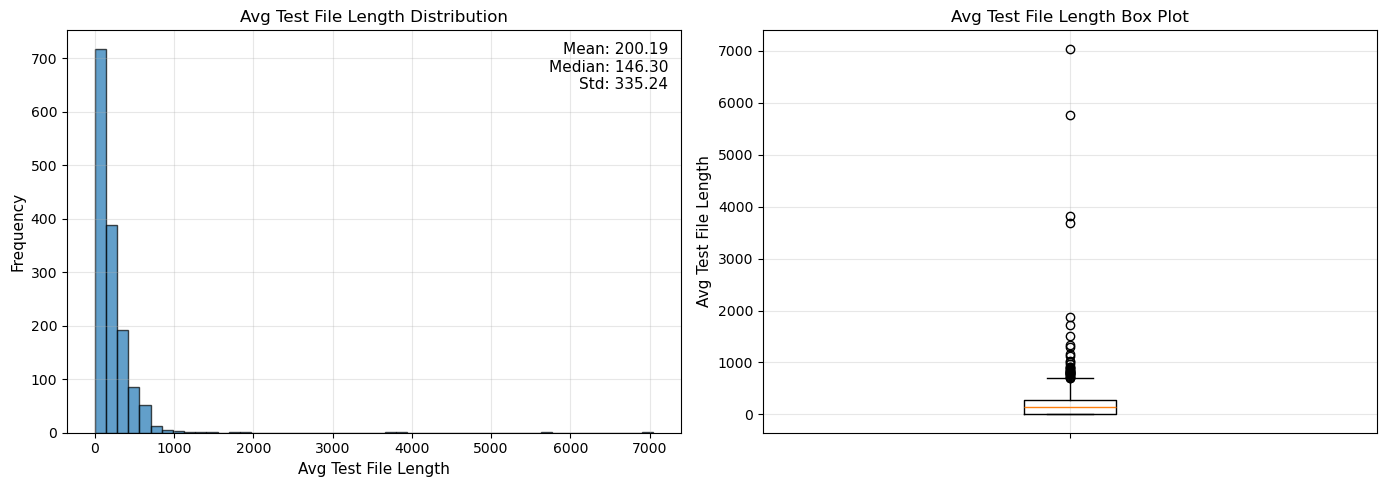

Exported: artifacts/distributions/avg_test_file_len_distribution.pdf


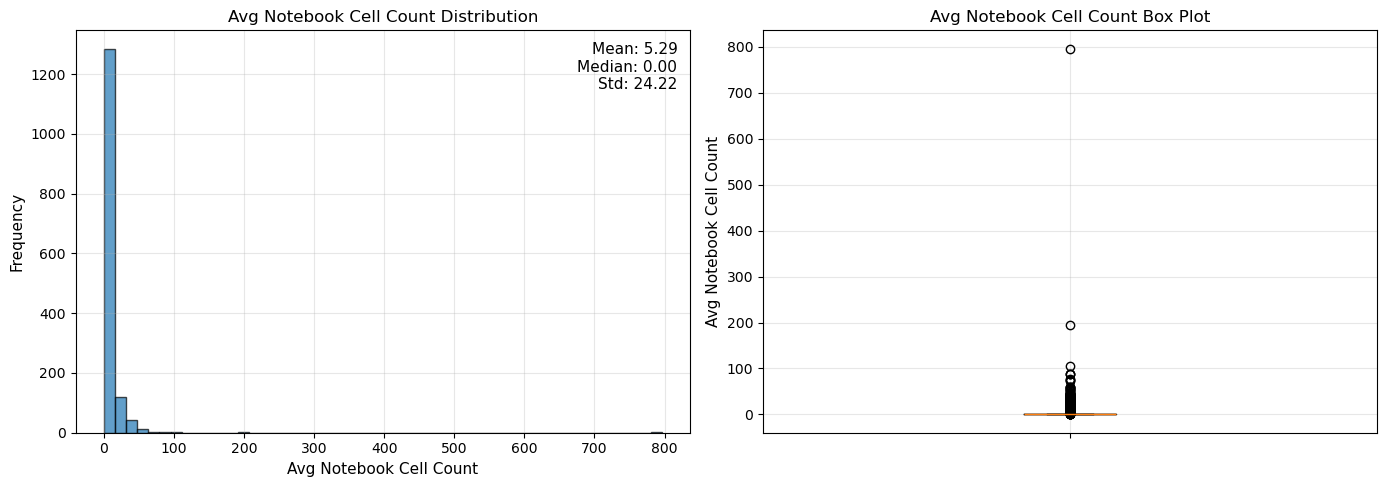

Exported: artifacts/distributions/avg_nb_cell_count_distribution.pdf


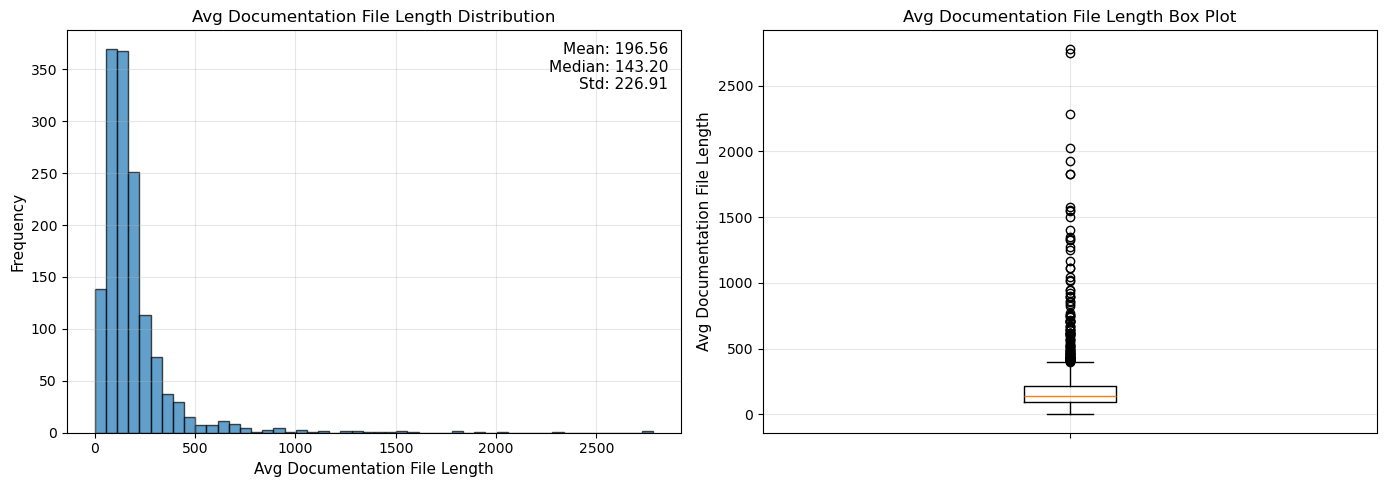

Exported: artifacts/distributions/avg_docs_file_len_distribution.pdf


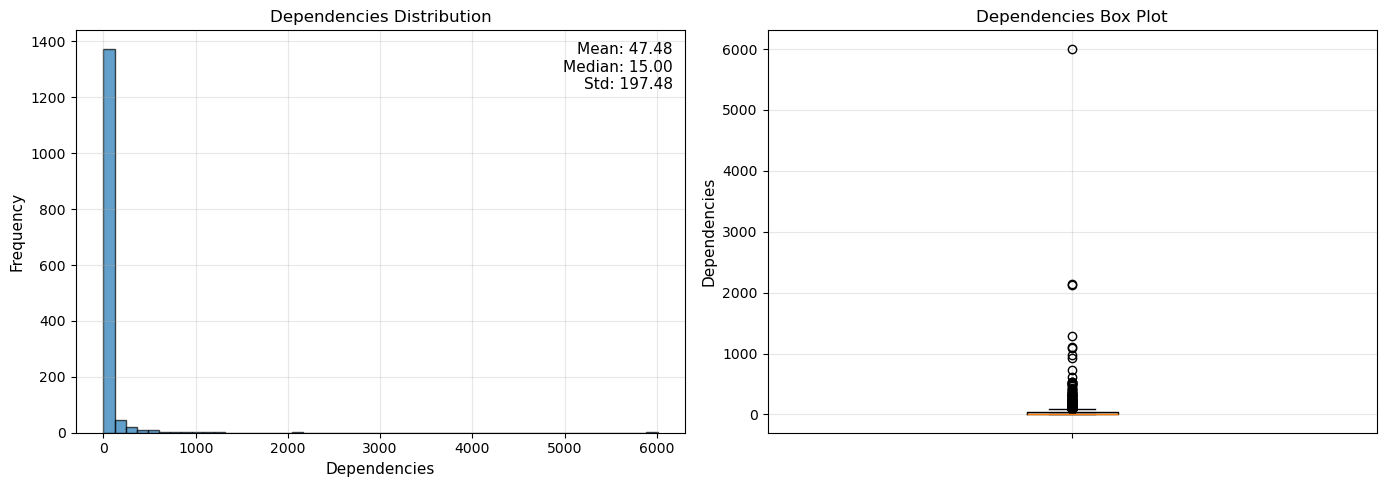

Exported: artifacts/distributions/num_dependencies_distribution.pdf


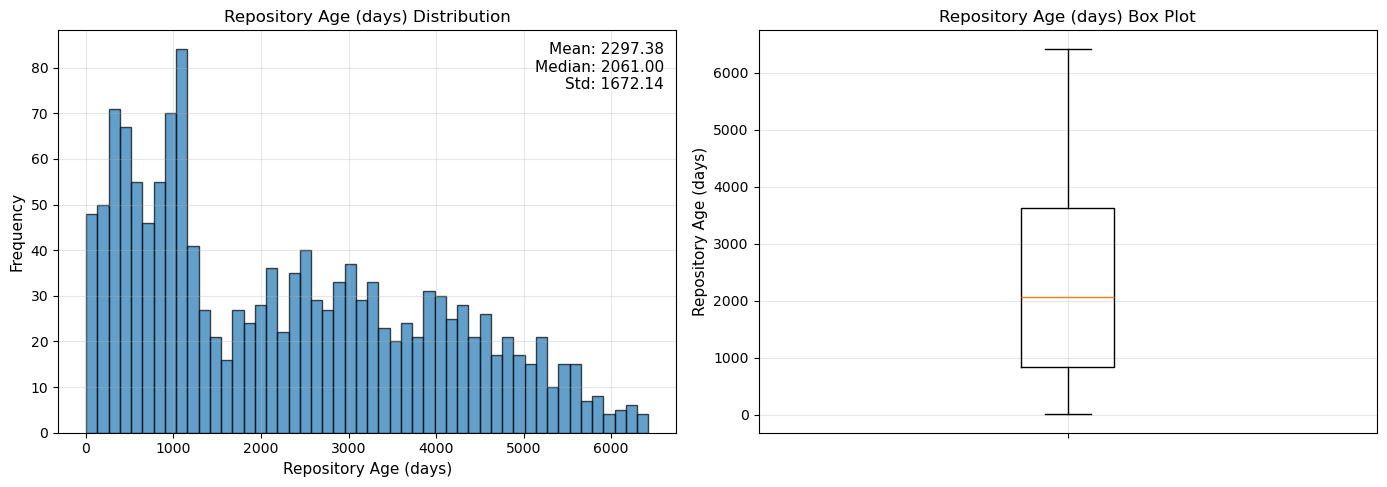

Exported: artifacts/distributions/repo_age_days_distribution.pdf


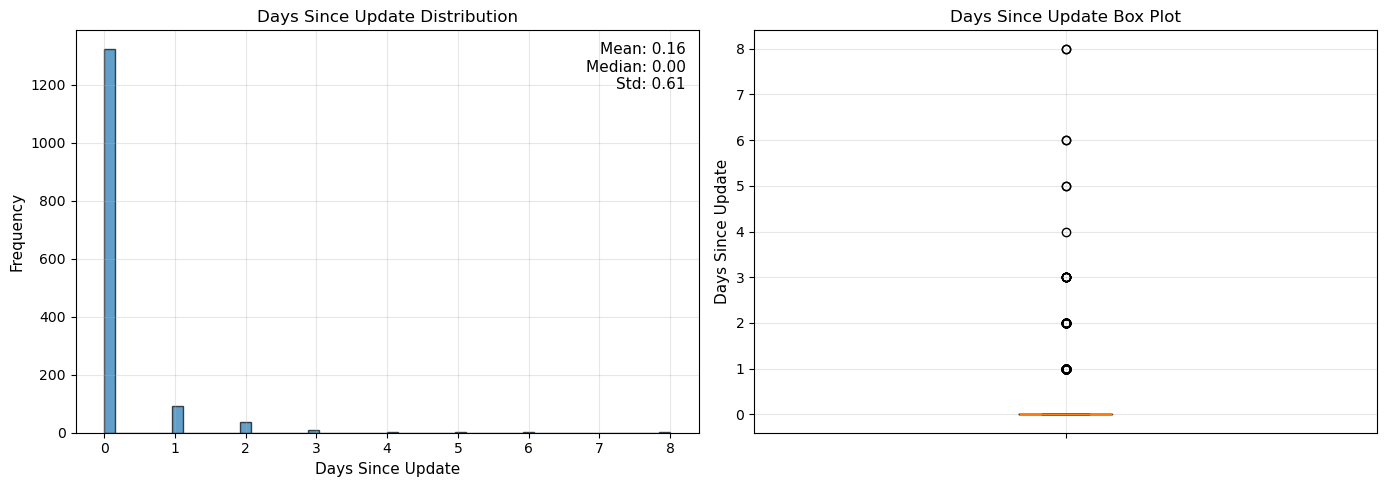

Exported: artifacts/distributions/recent_activity_days_distribution.pdf


In [350]:
continuous_features = [
    ("stars", "Star Count"),
    ("forks", "Fork Count"),
    ("repo_size_kb", "Repository Size (KB)"),
    ("open_issues_count", "Open Issues"),
    ("num_files", "Total Files"),
    ("num_py_files", "Python Files"),
    ("num_js_files", "JavaScript Files"),
    ("num_ts_files", "TypeScript Files"),
    ("num_html_files", "HTML Files"),
    ("num_css_files", "CSS Files"),
    ("num_json_files", "JSON Files"),
    ("num_sh_files", "Shell Scripts"),
    ("num_yaml_files", "YAML Files"),
    ("num_test_files", "Test Files"),
    ("test_file_ratio", "Test File Ratio"),
    ("num_docs_files", "Documentation Files"),
    ("num_notebooks", "Jupyter Notebooks"),
    ("other_extensions_count", "Other Extensions"),
    ("num_dirs", "Directories"),
    ("avg_files_per_dir", "Avg Files per Directory"),
    ("avg_py_file_len", "Avg Python File Length"),
    ("avg_test_file_len", "Avg Test File Length"),
    ("avg_nb_cell_count", "Avg Notebook Cell Count"),
    ("avg_docs_file_len", "Avg Documentation File Length"),
    ("num_dependencies", "Dependencies"),
    ("repo_age_days", "Repository Age (days)"),
    ("recent_activity_days", "Days Since Update"),
]

for feature, label in continuous_features:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    data = df[feature].dropna()
    ax1.hist(data, bins=50, edgecolor="black", alpha=0.7)
    ax1.set_xlabel(label)
    ax1.set_ylabel("Frequency")
    ax1.set_title(f"{label} Distribution")
    ax1.grid(axis="y", alpha=0.3)

    stats_text = (
        f"Mean: {data.mean():.2f}\nMedian: {data.median():.2f}\nStd: {data.std():.2f}"
    )
    ax1.text(
        0.98,
        0.97,
        stats_text,
        transform=ax1.transAxes,
        verticalalignment="top",
        horizontalalignment="right",
    )

    ax2.boxplot(data, vert=True)
    ax2.set_ylabel(label)
    ax2.set_title(f"{label} Box Plot")
    ax2.grid(axis="y", alpha=0.3)
    ax2.set_xticklabels([""])

    plt.tight_layout()
    export_path = distributions_dir / f"{feature}_distribution.pdf"
    plt.savefig(export_path, format="pdf", bbox_inches="tight")
    plt.show()
    print(f"Exported: {export_path}")

### 1.2 Boolean Feature Frequencies

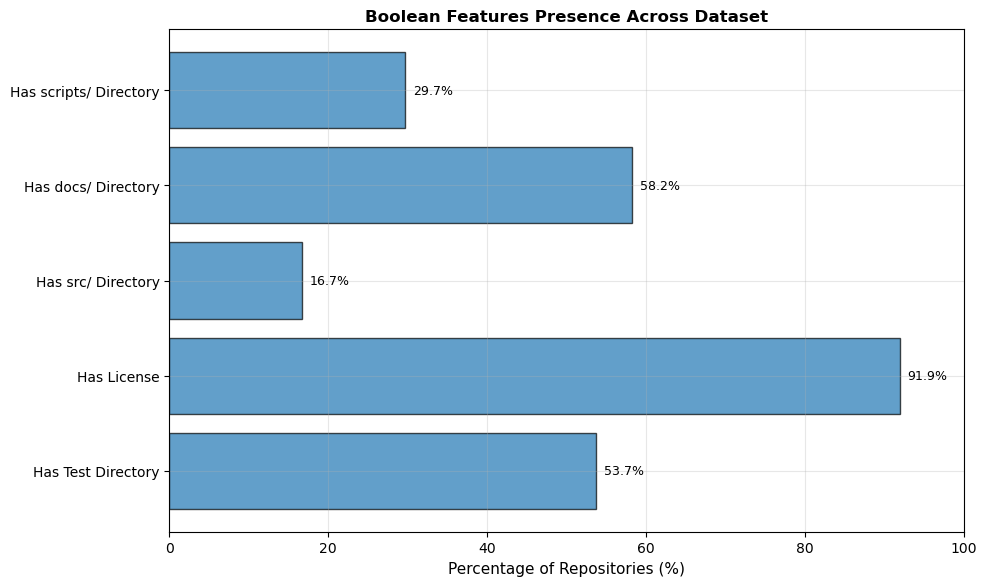

Exported: artifacts/distributions/boolean_features_frequency.pdf


In [351]:
bool_features = [
    ("has_dedicated_test_dir", "Has Test Directory"),
    ("has_license", "Has License"),
    ("has_src_dir", "Has src/ Directory"),
    ("has_docs_dir", "Has docs/ Directory"),
    ("has_scripts_dir", "Has scripts/ Directory"),
]

bool_data = []
for feature, label in bool_features:
    if feature in df.columns:
        pct = (df[feature].sum() / len(df)) * 100
        bool_data.append((label, pct))

fig, ax = plt.subplots(figsize=(10, 6))

labels = [item[0] for item in bool_data]
percentages = [item[1] for item in bool_data]

bars = ax.barh(labels, percentages, edgecolor="black", alpha=0.7)
ax.set_xlabel("Percentage of Repositories (%)")
ax.set_title("Boolean Features Presence Across Dataset", fontweight="bold")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.3)

for i, pct in enumerate(percentages):
    ax.text(pct + 1, i, f"{pct:.1f}%", va="center", fontsize=9)

plt.tight_layout()
export_path = distributions_dir / "boolean_features_frequency.pdf"
plt.savefig(export_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Exported: {export_path}")

## 2. Label Analysis & Configuration Patterns

### 2.1 Label Frequency Analysis

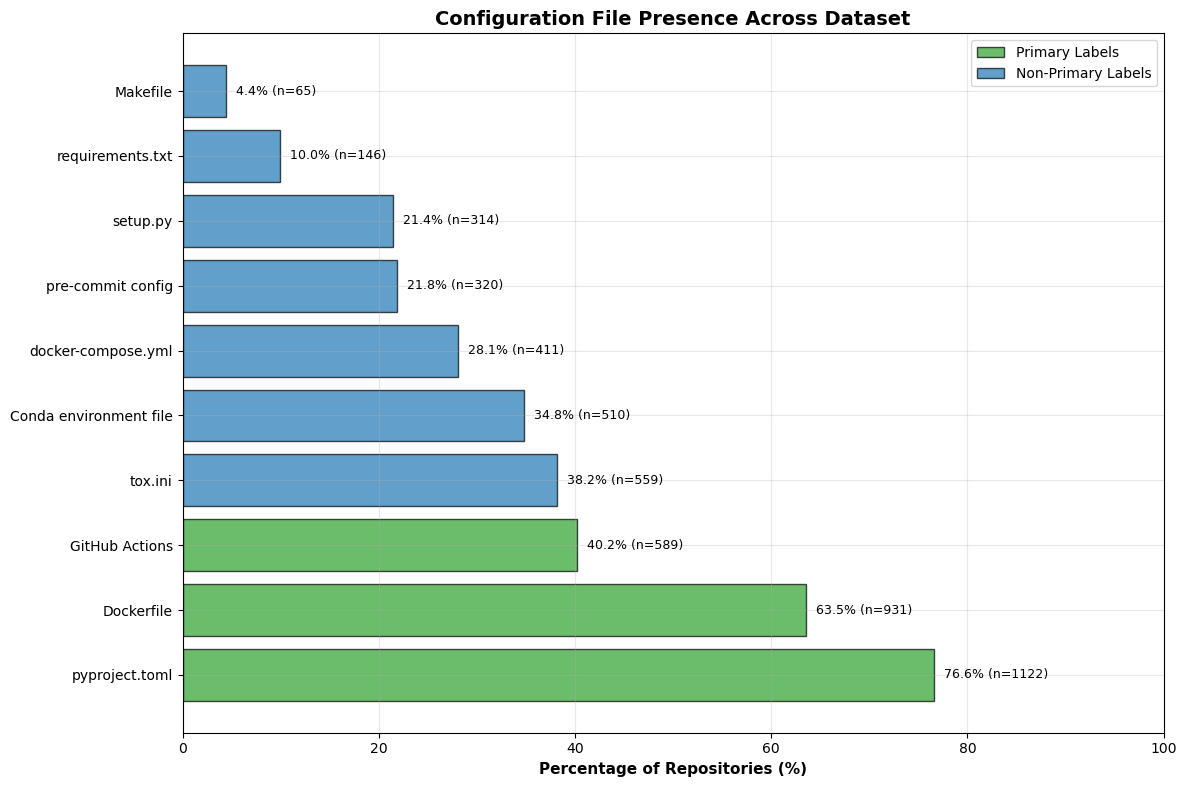

Exported: artifacts/labels/label_frequencies.pdf

Label presence summary:
  [PRIMARY] has_github_actions: 1122 (76.6%)
  [PRIMARY] has_pyproject_toml: 931 (63.5%)
  [PRIMARY] has_dockerfile: 589 (40.2%)
  has_requirements_txt: 559 (38.2%)
  has_precommit_config: 510 (34.8%)
  has_setup_py: 411 (28.1%)
  has_makefile: 320 (21.8%)
  has_docker_compose: 314 (21.4%)
  has_tox_ini: 146 (10.0%)
  has_conda_env_file: 65 (4.4%)


In [352]:
labels = {
    "has_pyproject_toml": "pyproject.toml",
    "has_dockerfile": "Dockerfile",
    "has_github_actions": "GitHub Actions",
    "has_tox_ini": "tox.ini",
    "has_conda_env_file": "Conda environment file",
    "has_docker_compose": "docker-compose.yml",
    "has_precommit_config": "pre-commit config",
    "has_setup_py": "setup.py",
    "has_requirements_txt": "requirements.txt",
    "has_makefile": "Makefile",
}

primary_labels = ["has_pyproject_toml", "has_dockerfile", "has_github_actions"]

label_freq = {}
for label in label_cols:
    count = df[label].sum()
    pct = (count / len(df)) * 100
    is_primary = label in primary_labels
    label_freq[label] = {"count": count, "percentage": pct, "is_primary": is_primary}

sorted_labels = sorted(
    label_freq.items(), key=lambda x: x[1]["percentage"], reverse=True
)
percentages = [item[1]["percentage"] for item in sorted_labels]
colors = ["#2ca02c" if item[1]["is_primary"] else "#1f77b4" for item in sorted_labels]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(labels.values(), percentages, color=colors, edgecolor="black", alpha=0.7)
ax.set_xlabel("Percentage of Repositories (%)", fontweight="bold")
ax.set_title(
    "Configuration File Presence Across Dataset", fontsize=14, fontweight="bold"
)
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.3)

for i, (pct, item) in enumerate(zip(percentages, sorted_labels, strict=False)):
    count = item[1]["count"]
    ax.text(pct + 1, i, f"{pct:.1f}% (n={count})", va="center", fontsize=9)

legend_elements = [
    Patch(facecolor="#2ca02c", edgecolor="black", alpha=0.7, label="Primary Labels"),
    Patch(
        facecolor="#1f77b4", edgecolor="black", alpha=0.7, label="Non-Primary Labels"
    ),
]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
export_path = labels_dir / "label_frequencies.pdf"
plt.savefig(export_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Exported: {export_path}")


print("\nLabel presence summary:")
for label, info in sorted_labels:
    marker = "[PRIMARY] " if info["is_primary"] else ""
    print(f"  {marker}{label}: {info['count']} ({info['percentage']:.1f}%)")

### 2.2 Multi-label Statistics

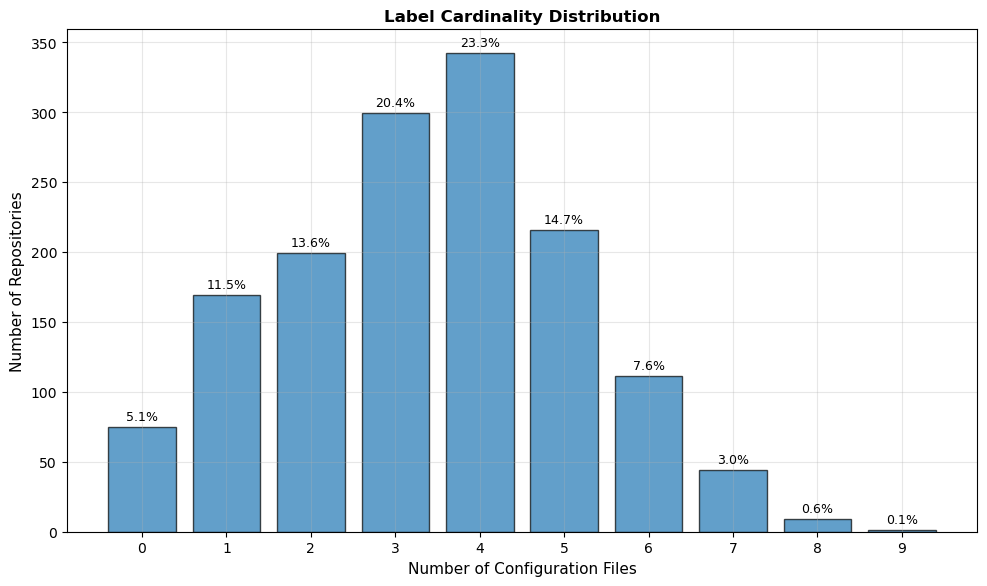

Exported: artifacts/labels/label_cardinality.pdf

Label Cardinality Statistics:
  Mean: 3.39
  Median: 3
  Mode: 4
  Min: 0
  Max: 9


In [353]:
df["label_count"] = df[label_cols].sum(axis=1)

cardinality_counts = df["label_count"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    cardinality_counts.index, cardinality_counts.values, edgecolor="black", alpha=0.7
)
ax.set_xlabel("Number of Configuration Files")
ax.set_ylabel("Number of Repositories")
ax.set_title("Label Cardinality Distribution", fontweight="bold")
ax.set_xticks(
    range(int(cardinality_counts.index.min()), int(cardinality_counts.index.max()) + 1)
)
ax.grid(axis="y", alpha=0.3)

total_repos = len(df)
for x, y in zip(cardinality_counts.index, cardinality_counts.values, strict=False):
    pct = (y / total_repos) * 100
    ax.text(x, y + 5, f"{pct:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
export_path = labels_dir / "label_cardinality.pdf"
plt.savefig(export_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Exported: {export_path}")

print("\nLabel Cardinality Statistics:")
print(f"  Mean: {df['label_count'].mean():.2f}")
print(f"  Median: {df['label_count'].median():.0f}")
print(f"  Mode: {df['label_count'].mode()[0]}")
print(f"  Min: {df['label_count'].min()}")
print(f"  Max: {df['label_count'].max()}")

Top 15 Label Combinations:
 1. pyproject.toml, GH Actions
    Count: 84 (5.7%)
 2. (none)
    Count: 75 (5.1%)
 3. pyproject.toml, GH Actions, pre-commit
    Count: 71 (4.8%)
 4. requirements.txt
    Count: 58 (4.0%)
 5. GH Actions
    Count: 55 (3.8%)
 6. pyproject.toml, Dockerfile, GH Actions, pre-commit
    Count: 39 (2.7%)
 7. pyproject.toml, Dockerfile, GH Actions, docker-compose
    Count: 37 (2.5%)
 8. pyproject.toml, Dockerfile, GH Actions, docker-compose, pre-commit
    Count: 36 (2.5%)
 9. pyproject.toml, Dockerfile, GH Actions
    Count: 31 (2.1%)
10. pyproject.toml
    Count: 29 (2.0%)
11. GH Actions, setup.py, requirements.txt
    Count: 28 (1.9%)
12. GH Actions, requirements.txt
    Count: 26 (1.8%)
13. Dockerfile, GH Actions, docker-compose, requirements.txt
    Count: 25 (1.7%)
14. pyproject.toml, GH Actions, tox.ini, pre-commit
    Count: 24 (1.6%)
15. pyproject.toml, GH Actions, pre-commit, Makefile
    Count: 21 (1.4%)


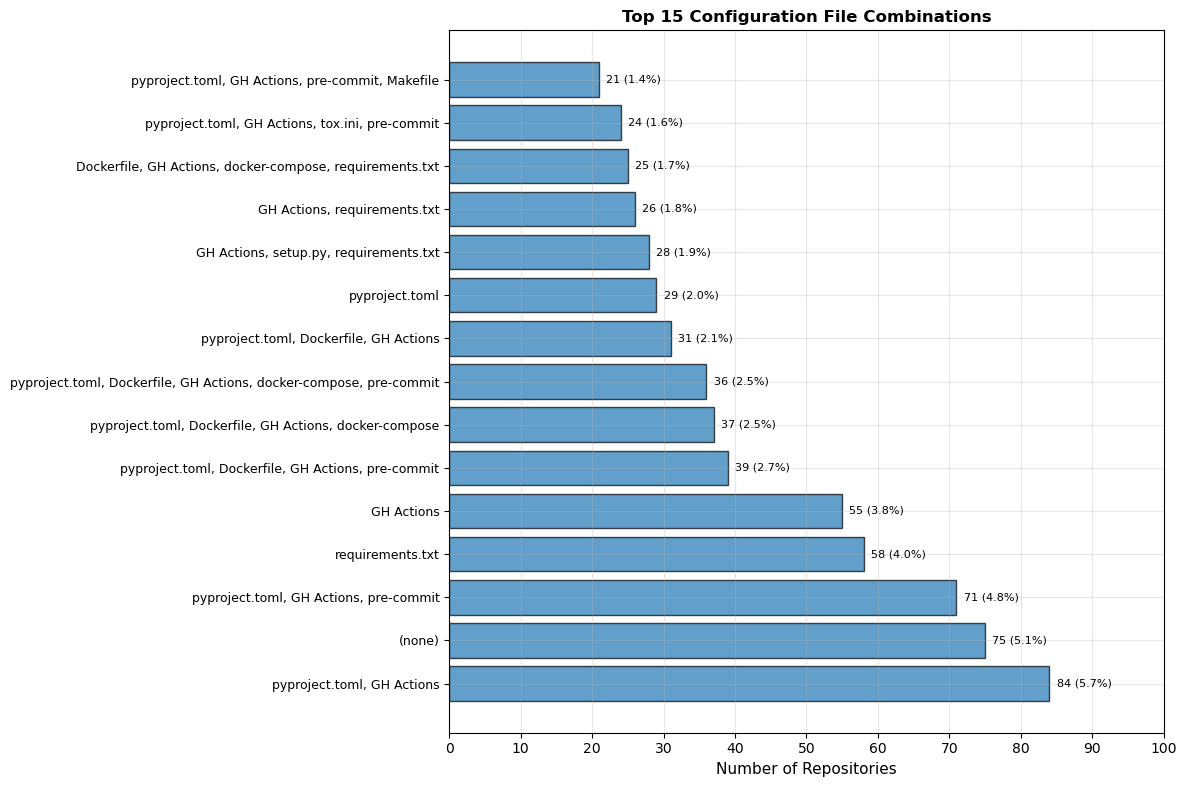

Exported: artifacts/labels/top_label_combinations.pdf


In [354]:
labels = {
    "has_pyproject_toml": "pyproject.toml",
    "has_dockerfile": "Dockerfile",
    "has_github_actions": "GH Actions",
    "has_tox_ini": "tox.ini",
    "has_conda_env_file": "conda env",
    "has_docker_compose": "docker-compose",
    "has_precommit_config": "pre-commit",
    "has_setup_py": "setup.py",
    "has_requirements_txt": "requirements.txt",
    "has_makefile": "Makefile",
}

label_combinations = df[label_cols].apply(
    lambda row: tuple(label_cols[i] for i, val in enumerate(row) if val), axis=1
)
combo_counts = label_combinations.value_counts().head(15)

print("Top 15 Label Combinations:")
for idx, (combo, count) in enumerate(combo_counts.items(), 1):
    pct = (count / len(df)) * 100
    combo_str = (
        ", ".join([labels.get(c, c.replace("has_", "")) for c in combo])
        if combo
        else "(none)"
    )
    print(f"{idx:2d}. {combo_str}")
    print(f"    Count: {count} ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(12, 8))

combo_labels = []
for combo in combo_counts.index:
    if combo:
        label_names = [labels.get(c, c.replace("has_", "")) for c in combo]
        combo_labels.append(", ".join(label_names))
    else:
        combo_labels.append("(none)")
combo_values = combo_counts.values

bars = ax.barh(range(len(combo_labels)), combo_values, edgecolor="black", alpha=0.7)
ax.set_yticks(range(len(combo_labels)))
ax.set_yticklabels(combo_labels, fontsize=9)
ax.set_xticks(np.arange(0, max(combo_values) + 20, 10))
ax.set_xlabel("Number of Repositories")
ax.set_title("Top 15 Configuration File Combinations", fontweight="bold")
ax.grid(axis="x", alpha=0.3)

for i, count in enumerate(combo_values):
    pct = (count / len(df)) * 100
    ax.text(count + 1, i, f"{count} ({pct:.1f}%)", va="center", fontsize=8)

plt.tight_layout()
export_path = labels_dir / "top_label_combinations.pdf"
plt.savefig(export_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Exported: {export_path}")

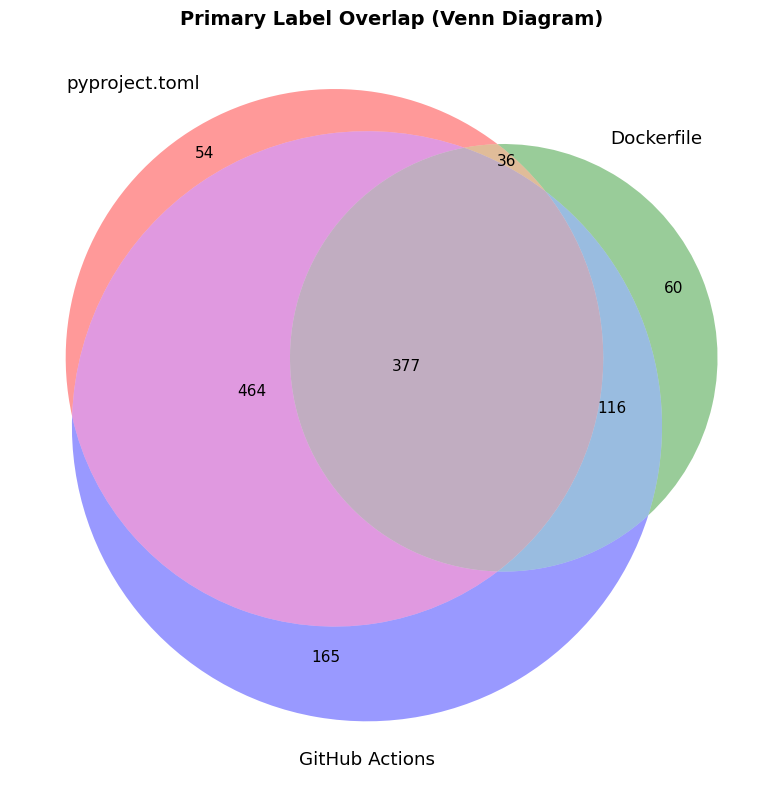

Exported: artifacts/labels/primary_labels_venn.pdf

Primary Label Overlap Statistics:
  All three: 377
  pyproject + Dockerfile: 36
  pyproject + GH Actions: 464
  Dockerfile + GH Actions: 116
  Only pyproject: 54
  Only Dockerfile: 60
  Only GH Actions: 165


In [355]:
pyproject = set(df[df["has_pyproject_toml"]].index)
dockerfile = set(df[df["has_dockerfile"]].index)
gh_actions = set(df[df["has_github_actions"]].index)

fig, ax = plt.subplots(figsize=(10, 8))

venn = venn3(
    [pyproject, dockerfile, gh_actions],
    set_labels=("pyproject.toml", "Dockerfile", "GitHub Actions"),
    ax=ax,
)

ax.set_title("Primary Label Overlap (Venn Diagram)", fontsize=14, fontweight="bold")

plt.tight_layout()
export_path = labels_dir / "primary_labels_venn.pdf"
plt.savefig(export_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Exported: {export_path}")

print("\nPrimary Label Overlap Statistics:")
print(f"  All three: {len(pyproject & dockerfile & gh_actions)}")
len_pyproject_dockerfile = len(pyproject & dockerfile) - len(
    pyproject & dockerfile & gh_actions
)
print(f"  pyproject + Dockerfile: {len_pyproject_dockerfile}")
len_pyproject_gh_actions = len(pyproject & gh_actions) - len(
    pyproject & dockerfile & gh_actions
)
print(f"  pyproject + GH Actions: {len_pyproject_gh_actions}")
len_dockerfile_gh_actions = len(dockerfile & gh_actions) - len(
    pyproject & dockerfile & gh_actions
)
print(f"  Dockerfile + GH Actions: {len_dockerfile_gh_actions}")
print(f"  Only pyproject: {len(pyproject - dockerfile - gh_actions)}")
print(f"  Only Dockerfile: {len(dockerfile - pyproject - gh_actions)}")
print(f"  Only GH Actions: {len(gh_actions - pyproject - dockerfile)}")

## 3. Detailed Distributions

### 3.2 Star Distribution Analysis


Star Distribution Statistics:
  Mean: 15701.49
  Median: 8625
  Min: 4395
  Max: 418056
  25th percentile: 5829
  75th percentile: 15582
  95th percentile: 48160


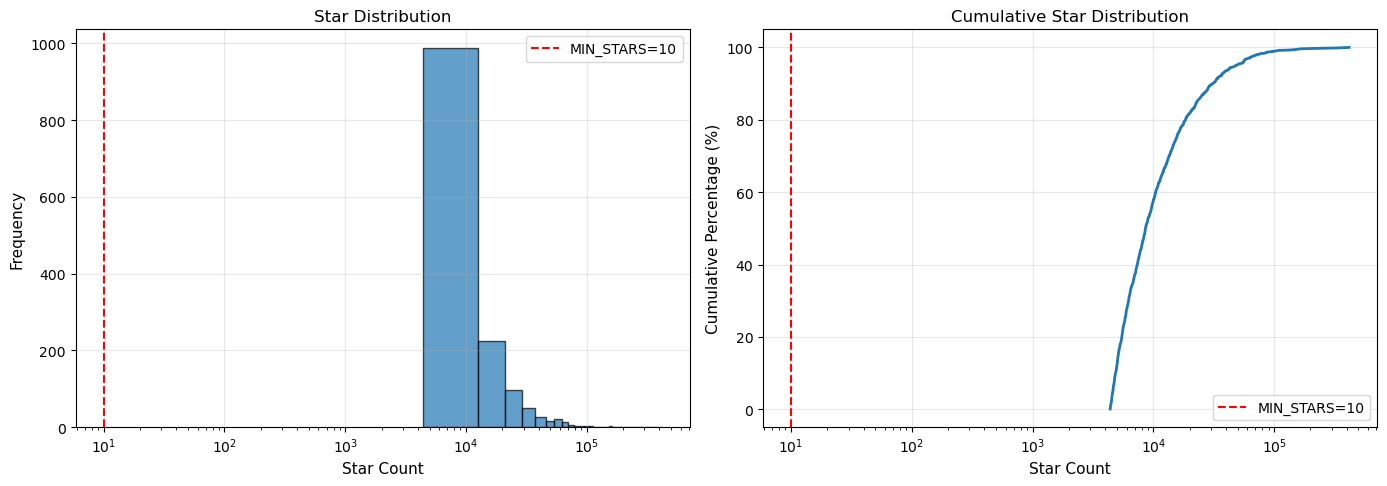

Exported: artifacts/distributions/detailed/star_distribution.pdf


In [356]:
stars_data = df["stars"].dropna()

print("\nStar Distribution Statistics:")
print(f"  Mean: {stars_data.mean():.2f}")
print(f"  Median: {stars_data.median():.0f}")
print(f"  Min: {stars_data.min():.0f}")
print(f"  Max: {stars_data.max():.0f}")
print(f"  25th percentile: {stars_data.quantile(0.25):.0f}")
print(f"  75th percentile: {stars_data.quantile(0.75):.0f}")
print(f"  95th percentile: {stars_data.quantile(0.95):.0f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(stars_data, bins=50, edgecolor="black", alpha=0.7)
ax1.set_xlabel("Star Count")
ax1.set_ylabel("Frequency")
ax1.set_title("Star Distribution")
ax1.set_xscale("log")
ax1.grid(axis="y", alpha=0.3)
ax1.axvline(10, color="red", linestyle="--", label="MIN_STARS=10")
ax1.legend()

sorted_stars = np.sort(stars_data)
cumulative = np.arange(1, len(sorted_stars) + 1) / len(sorted_stars) * 100

ax2.plot(sorted_stars, cumulative, linewidth=2)
ax2.set_xlabel("Star Count")
ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_title("Cumulative Star Distribution")
ax2.set_xscale("log")
ax2.grid(alpha=0.3)
ax2.axvline(10, color="red", linestyle="--", label="MIN_STARS=10")
ax2.legend()

plt.tight_layout()
export_path = distributions_detailed_dir / "star_distribution.pdf"
plt.savefig(export_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Exported: {export_path}")

### 3.3 Temporal Characteristics

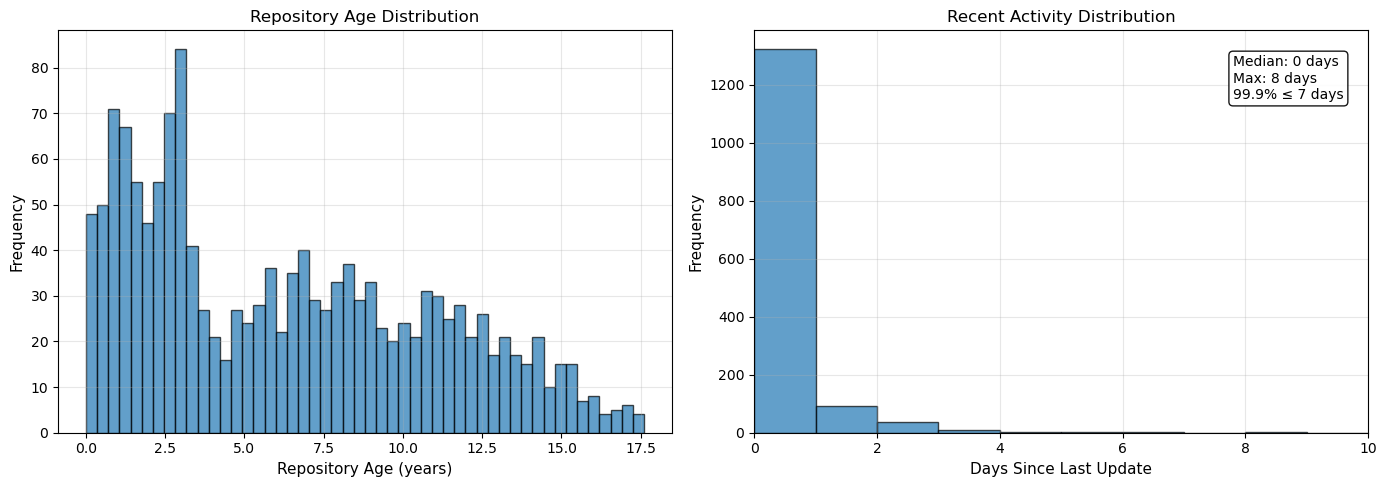

Exported: artifacts/distributions/detailed/temporal_characteristics.pdf


In [357]:
age_data = df["repo_age_days"].dropna()
activity_data = df["recent_activity_days"].dropna()

median_act = activity_data.median()
max_act = activity_data.max()
pct_7 = (activity_data <= 7).sum() / len(activity_data) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

age_years = age_data / 365
ax1.hist(age_years, bins=50, edgecolor="black", alpha=0.7)

ax1.set_xlabel("Repository Age (years)")
ax1.set_ylabel("Frequency")
ax1.set_title("Repository Age Distribution")
ax1.grid(axis="y", alpha=0.3)

bins = np.arange(0, 11, 1)
ax2.hist(activity_data, bins=bins, edgecolor="black", alpha=0.7)

ax2.set_xlim(0, 10)
ax2.set_xlabel("Days Since Last Update")
ax2.set_ylabel("Frequency")
ax2.set_title("Recent Activity Distribution")
ax2.grid(axis="y", alpha=0.3)

ax2.text(
    0.78,
    0.83,
    f"Median: {median_act:.0f} days\n"
    f"Max: {max_act:.0f} days\n"
    f"{pct_7:.1f}% ≤ 7 days",
    transform=ax2.transAxes,
    fontsize=10,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
)

plt.tight_layout()

export_path = distributions_detailed_dir / "temporal_characteristics.pdf"
plt.savefig(export_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"Exported: {export_path}")